# K-means clustering
---
K-Means is a popular unsupervised machine learning algorithm that partitions data into
 distinct, non-overlapping clusters by minimizing the distance between data points and their cluster centroids. It iteratively assigns points to the nearest center and recalculates centroids until convergence. It is widely used for pattern discovery and customer segmentation.

Source link: https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/

In [4]:
from tarfile import data_filter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans

from sklearn.cluster import KMeans

In [5]:
data = pd.read_csv('../dataset/pca_matrix.csv')
data

,0,1,2,3,4,5,6
0,-1.696395,-1.122584,-0.491562,0.719521,-0.079830,-0.118234,0.808993
1,-1.215681,2.435638,-0.694658,-0.098843,-0.803019,0.917777,-0.322969
2,0.935853,-0.385202,0.025953,1.293844,1.987285,0.682139,-1.624721
3,-1.614638,-0.724586,-0.272358,1.086116,0.427814,-0.082982,0.687001
4,0.223701,-0.783610,1.184434,0.721353,-0.801243,-0.525879,0.788893
...,...,...,...,...,...,...,...
8631,-2.221637,-1.328411,-1.643826,-1.421354,0.175573,-3.518499,-1.313848
8632,-0.362326,-2.032249,0.875053,-2.800940,0.313566,-2.808854,-1.549426
8633,-0.930026,-1.841236,0.350037,-2.351591,0.219492,-3.090269,-1.421757
8634,-2.356010,-0.718730,-1.048522,-1.776467,0.552690,-3.333452,-0.996810


In [15]:
df_original = pd.read_csv('../dataset/cleaned_data.csv')
df_original

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


For each value of
`k` from 1 to 10, a K-Means model is trained on the dataset. The algorithm computes the within-cluster sum of squares (inertia), which measures how close the data points are to their assigned cluster centroids.

The inertia values are stored and then plotted against the number of clusters. As the number of clusters increases, inertia decreases because the clusters become more compact.

The optimal number of clusters is typically chosen at the “elbow point”, where the decrease in inertia begins to slow down significantly. This point indicates a good balance between model complexity and clustering performance.

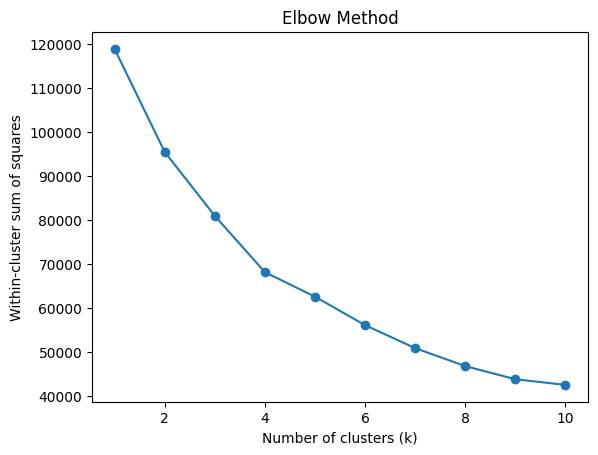

In [6]:
inertia = []

K = range(1, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=43)
    model.fit(data)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow Method")
plt.show()

$$\LARGE
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

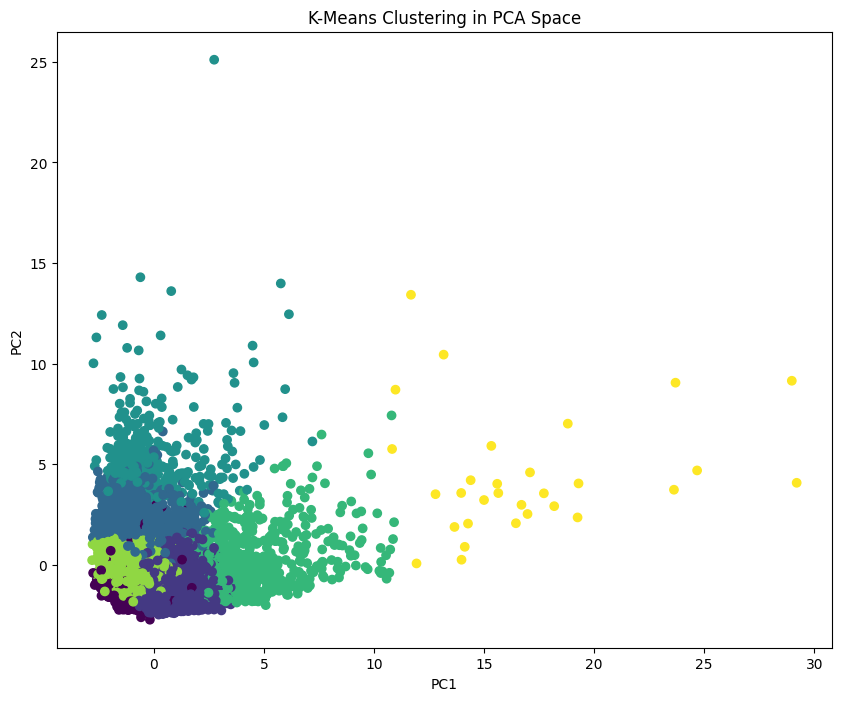

In [14]:
k = 7

kmeans = KMeans(n_clusters=k, random_state=43)

clusters = kmeans.fit_predict(data)

data["cluster"] = clusters


plt.figure(figsize=(10, 8))
plt.scatter(
    data["0"],
    data["1"],
    c=data["cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering in PCA Space")

plt.show()

In [16]:
df_original["cluster"] = clusters

In [17]:
df_original

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,5
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,5
4,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8631,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,5
8632,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8633,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,5
8634,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,5
